### Some Theory

##### Types of data used for I/O:
- Text - '12345' as a sequence of unicode chars
- Binary - 12345 as a sequence of bytes of its binary equivalent

##### Hence there are 2 file types to deal with
- Text files - All program files are text files
- Binary Files - Images,music,video,exe files

### How File I/O is done in most programming languages

- Open a file
- Read/Write data
- Close the file

### Writing to a file

In [1]:
# case 1 - if the file is not present
f = open('sample.txt','w')
f.write('Hello world')
f.close()
# since file is closed hence this will not work
# f.write('hello')

In [2]:
# Write multiple strings
f = open('sample1.txt','w')
f.write('Hey__ Aman_!!')
f.write('Ary you busy now!')
f.close()

In [3]:
# Case 2 - if the file is already present
f = open('sample.txt','w')
f.write('Hey!! this is new text')
f.close()

In [4]:
# How exactly open() works?


In [5]:
# Problem with w mode
# Introducing append mode
f = open('sample.txt','a')
f.write('\nHey!! This is second text')
f.close()

In [6]:
L = ['hello\n','hi\n','how are you\n','I am fine']

f = open('sample.txt','w')
f.writelines(L)
f.close()

In [7]:
# Reading form a files
# -> using read()
f = open('sample.txt','r')
s = f.read()
print(s)
f.close()

hello
hi
how are you
I am fine


In [8]:
# reading upto n chars
f = open('sample.txt','r')
s = f.read(10)
print(s)
f.close()

hello
hi
h


In [9]:
f = open('sample.txt','r')
print(f.readline(),end='')
print(f.readline(),end='')
f.close()

hello
hi


In [10]:
# reading entire using readline
f = open('sample.txt','r')
while True:
    data = f.readline()

    if data == '':
        break
    else:
        print(data,end='')

f.close()

hello
hi
how are you
I am fine

In [11]:
# Reading entire using readline
f = open('sample.txt','r')


### Using Context Manager (With)

- It's a good idea to close a file after usage as it will free up the resources
- If we dont close it, garbage collector would close it
- with keyword closes the file as soon as the usage is over

In [12]:
# With : It automatically close the file.
with open('sample.txt','w') as f:
    f.write('Hey this is new code')
    f.write('\nMy name is Rahul')
    f.write('\nI am going Jaipur now')

In [13]:
# try f.read() now
with open('sample.txt','r') as f:
    print(f.read())

Hey this is new code
My name is Rahul
I am going Jaipur now


In [14]:
# Moving within a file -> 10 char then 10 char
with open('sample.txt','r') as f:
    print(f.read(10))
    print(f.read(10))

Hey this i
s new code


In [15]:
# benefit -> to load a big file in a meamory.
big_L = ['hello world' for i in range(1000)]

with open('sample.txt','w') as f:
    f.writelines(big_L)

In [16]:
with open('sample.txt','r') as f:

    chunk_size = 100

    while len(f.read(chunk_size)) > 0:
        print(f.read(chunk_size),end='*')
        f.read(chunk_size)

ello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhe*o worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello*orldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello wo*dhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello world*llo worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhel* worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello *rldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello wor*hello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldh*lo worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhell*worldhello worldhello worldhello worldhello worldhello worldhello worldhello worldhello wor

In [17]:
# seek and tell function
with open('sample.txt','r') as f:
    print(f.read(10))
    print(f.tell())
    print(f.seek(0))
    print(f.read(10))
    print(f.tell())

hello worl
10
0
hello worl
10


In [18]:
# seek during write
with open('sample.txt','w') as f:
    f.write('Hello')
    f.seek(0)
    f.write('x')

### Problems with working in text mode

- can't work with binary files like images
- not good for other data types like int/float/list/tuples

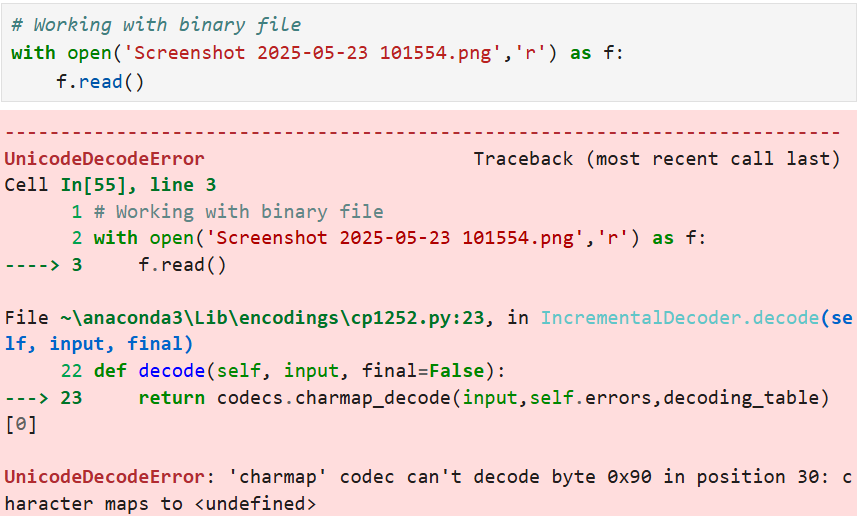

In [19]:
# # working with binary file
# with open('Screenshot 2025-05-23 101554.png','rb') as f:
#     with open('screenshot_copy.png','wb') as wf:
#         wf.write(f.read())

# You can add with yourself beecaus the kaggle not give the permit to add image.

In [20]:
# working with other data types
with open('sample.txt','w') as f:
    # f.write(5)
    f.write('5')

In [21]:
d = {
    'name': 'Aman',
    'age': 44,
    'gender': 'Male'
}

with open('sample.txt','w') as f:
    f.write(str(d))

In [22]:
with open('sample.txt','r') as f:
    print(f.read())
    print(type(f.read()))

{'name': 'Aman', 'age': 44, 'gender': 'Male'}
<class 'str'>


### Serialization and Deserialization

- **Serialization** - process of converting python data types to JSON format
- **Deserialization** - process of converting JSON to python data types

#### What is JSON?


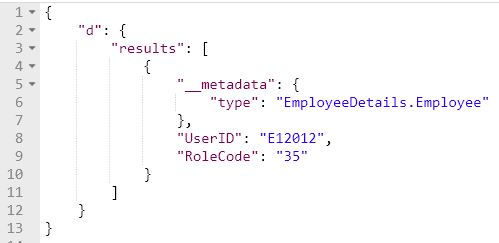

In [23]:
# serialization using json formate
# list
import json 
l = [1,2,3,4]
with open ('demo.json','w') as f:
    json.dump(l,f)

In [24]:
d = {
    'name': 'Aman',
    'age': 44,
    'gender': 'Male'
}
with open ('demo.json','w') as f:
    json.dump(d,f,indent=4)

### Serializing and Deserializing custom objects

In [25]:
class Person:

  def __init__(self,fname,lname,age,gender):
    self.fname = fname
    self.lname = lname
    self.age = age
    self.gender = gender

# format to printed in
# -> Nitish Singh age -> 33 gender -> male

In [26]:
person = Person('Nitish','Singh',33,'male')

In [27]:
# As a string
import json

def show_object(person):
  if isinstance(person,Person):
    return "{} {} age -> {} gender -> {}".format(person.fname,person.lname,person.age,person.gender)

with open('demo.json','w') as f:
  json.dump(person,f,default=show_object)

In [28]:
# As a dict
import json

def show_object(person):
  if isinstance(person,Person):
    return {'name':person.fname + ' ' + person.lname,'age':person.age,'gender':person.gender}

with open('demo.json','w') as f:
  json.dump(person,f,default=show_object,indent=4)

In [29]:
# indent arrtribute
# As a dict

In [30]:
# deserializing
import json

with open('demo.json','r') as f:
  d = json.load(f)
  print(d)
  print(type(d))

{'name': 'Nitish Singh', 'age': 33, 'gender': 'male'}
<class 'dict'>


### Pickling
`Pickling` is the process whereby a Python object hierarchy is converted into a byte stream, and `unpickling` is the inverse operation, whereby a byte stream (from a binary file or bytes-like object) is converted back into an object hierarchy.

In [31]:
class Person:

  def __init__(self,name,age):
    self.name = name
    self.age = age

  def display_info(self):
    print('Hi my name is',self.name,'and I am ',self.age,'years old')

In [32]:
p = Person('nitish',33)

In [33]:
# pickle dump
import pickle
with open('person.pkl','wb') as f:
  pickle.dump(p,f)

In [34]:
# pickle load
import pickle
with open('person.pkl','rb') as f:
  p = pickle.load(f)

p.display_info()

Hi my name is nitish and I am  33 years old


### Pickle Vs Json

- Pickle lets the user to store data in binary format. JSON lets the user store data in a human-readable text format.